In [1]:
pip install --upgrade scikit-learn

  Using cached scikit_learn-1.5.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (13 kB)
Using cached scikit_learn-1.5.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (13.3 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.4.2
    Uninstalling scikit-learn-1.4.2:
      Successfully uninstalled scikit-learn-1.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sktime 0.26.0 requires scikit-learn<1.5.0,>=0.24, but you have scikit-learn 1.5.2 which is incompatible.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/content/Breast_Cancer_Mortality_Survival_Dataset.csv')

Data Prep

In [4]:
df.head(5)

,Patient ID,Moth of Birth,Age,Sex,Race,Marital Status,Occupation Code,Adopted Status,T Stage,N Stage,...,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Mortality_Status
0,A0012,12,68.0,Female,White,Married,11.0,1,T1,N1,...,Poorly differentiated,3,Regional,4.0,Positive,Positive,24,1,60,Alive
1,A0013,12,50.0,Female,White,Married,11.0,0,T2,N2,...,Moderately differentiated,2,Regional,35.0,Positive,Positive,14,5,62,Alive
2,A0014,11,58.0,Female,White,Divorced,9.0,0,T3,N3,...,Moderately differentiated,2,Regional,63.0,Positive,Positive,14,7,75,Alive
3,A0015,3,58.0,Female,White,Married,10.0,0,T1,N1,...,Poorly differentiated,3,Regional,18.0,Positive,Positive,2,1,84,Alive
4,A0016,1,47.0,Female,White,Married,12.0,0,T2,N1,...,Poorly differentiated,3,Regional,41.0,Positive,Positive,3,1,50,Alive


In [5]:
df.tail(5)

,Patient ID,Moth of Birth,Age,Sex,Race,Marital Status,Occupation Code,Adopted Status,T Stage,N Stage,...,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Mortality_Status
4019,A4031,1,62.0,Female,Other,Married,8.0,1,T1,N1,...,Moderately differentiated,2,Regional,9.0,Positive,Positive,1,1,49,Alive
4020,A4032,5,56.0,Female,White,Divorced,3.0,0,T2,N2,...,Moderately differentiated,2,Regional,46.0,Positive,Positive,14,8,69,Alive
4021,A4033,2,68.0,Female,White,Married,2.0,1,T2,N1,...,Moderately differentiated,2,Regional,22.0,Positive,Negative,11,3,69,Alive
4022,A4034,10,58.0,Female,Black,Divorced,8.0,0,T2,N1,...,Moderately differentiated,2,Regional,44.0,Positive,Positive,11,1,72,Alive
4023,A4035,5,46.0,Female,White,Married,11.0,1,T2,N1,...,Moderately differentiated,2,Regional,30.0,Positive,Positive,7,2,100,Alive


In [6]:
df.shape

(4024, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Patient ID              4024 non-null   object 
 1   Moth of Birth           4024 non-null   int64  
 2   Age                     4015 non-null   float64
 3   Sex                     3947 non-null   object 
 4   Race                    4024 non-null   object 
 5   Marital Status          4024 non-null   object 
 6   Occupation Code         4021 non-null   float64
 7   Adopted Status          4024 non-null   int64  
 8   T Stage                 4024 non-null   object 
 9   N Stage                 4024 non-null   object 
 10  6th Stage               4024 non-null   object 
 11  differentiate           4024 non-null   object 
 12  Grade                   4024 non-null   int64  
 13  A Stage                 4024 non-null   object 
 14  Tumor Size              4021 non-null   

In [8]:
df.describe()

,Moth of Birth,Age,Occupation Code,Adopted Status,Grade,Tumor Size,Survival Months
count,4024.000000,4015.000000,4021.000000,4024.000000,4024.000000,4021.000000,4024.000000
mean,6.481362,54.094396,8.427257,0.496769,2.150596,30.419299,71.472167
std,3.475442,11.417118,4.637345,0.500052,0.638234,21.161080,25.361855
min,1.000000,30.000000,1.000000,0.000000,1.000000,-75.000000,1.000000
25%,3.000000,47.000000,4.000000,0.000000,2.000000,16.000000,56.000000
50%,6.000000,54.000000,8.000000,0.000000,2.000000,25.000000,73.000000
75%,10.000000,61.000000,12.000000,1.000000,3.000000,38.000000,90.000000
max,12.000000,502.000000,16.000000,1.000000,4.000000,140.000000,760.000000


In [9]:
df[df['Age'] > 100]

,Patient ID,Moth of Birth,Age,Sex,Race,Marital Status,Occupation Code,Adopted Status,T Stage,N Stage,...,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Mortality_Status
522,A0534,4,502.0,Female,White,Married,7.0,1,T2,N3,...,Moderately differentiated,2,Distant,29.0,Positive,Positive,29,28,40,Dead


In [10]:
unique_values = df['Sex'].unique()
print(unique_values)

['Female' nan]


In [11]:
unique_values = df['Race'].unique()
print(unique_values)

['White' 'Black' 'Other']


In [5]:
df.isnull().sum()

,0
Patient ID,0
Moth of Birth,0
Age,9
Sex,77
Race,0
Marital Status,0
Occupation Code,3
Adopted Status,0
T Stage,0
N Stage,0


In [13]:
df.isna().sum()/len(df)*100

,0
Patient ID,0.000000
Moth of Birth,0.000000
Age,0.223658
Sex,1.913519
Race,0.000000
Marital Status,0.000000
Occupation Code,0.074553
Adopted Status,0.000000
T Stage,0.000000
N Stage,0.000000


In [6]:
df_clean = df.dropna()

In [7]:
df_clean = df_clean.drop(522)

In [16]:
df_clean.shape

(3927, 21)

In [17]:
df_clean[df_clean['Age'] > 100]

,Patient ID,Moth of Birth,Age,Sex,Race,Marital Status,Occupation Code,Adopted Status,T Stage,N Stage,...,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Mortality_Status


In [18]:
unique_values = df['Mortality_Status'].unique()
print(unique_values)

['Alive' 'Dead' nan 'ALIVE' 'DEAD' 'alive' 'dead']


In [47]:
df_clean['Mortality_Status'] = df_clean['Mortality_Status'].str.lower()

In [20]:
unique_values = df_clean['Mortality_Status'].unique()
print(unique_values)

['alive' 'dead']


In [21]:
unique_values = df_clean['T Stage '].unique()
print(unique_values)

['T1' 'T2' 'T3' 'T4']


In [22]:
df_clean.columns

Index(['Patient ID ', 'Moth of Birth', 'Age', 'Sex', 'Race', 'Marital Status',
       'Occupation Code', 'Adopted Status', 'T Stage ', 'N Stage', '6th Stage',
       'differentiate', 'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status',
       'Progesterone Status', 'Regional Node Examined',
       'Reginol Node Positive', 'Survival Months', 'Mortality_Status'],
      dtype='object')

In [8]:
df_clean = df_clean.rename({'Patient ID ':"ID",'Moth of Birth':"MOB", 'T Stage ':"T Stage",
                            'Reginol Node Positive': "Regional Node Positive",}, axis=1)

In [24]:
df_clean.columns

Index(['ID', 'MOB', 'Age', 'Sex', 'Race', 'Marital Status', 'Occupation Code',
       'Adopted Status', 'T Stage', 'N Stage', '6th Stage', 'differentiate',
       'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status',
       'Progesterone Status', 'Regional Node Examined',
       'Regional Node Positive', 'Survival Months', 'Mortality_Status'],
      dtype='object')

In [25]:
df_clean.shape

(3927, 21)

In [9]:
df_clean_A = df_clean.drop(['ID','Sex','MOB' ], axis = 1)

In [27]:
df_clean_A

,Age,Race,Marital Status,Occupation Code,Adopted Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Regional Node Positive,Survival Months,Mortality_Status
0,68.0,White,Married,11.0,1,T1,N1,IIA,Poorly differentiated,3,Regional,4.0,Positive,Positive,24,1,60,alive
1,50.0,White,Married,11.0,0,T2,N2,IIIA,Moderately differentiated,2,Regional,35.0,Positive,Positive,14,5,62,alive
2,58.0,White,Divorced,9.0,0,T3,N3,IIIC,Moderately differentiated,2,Regional,63.0,Positive,Positive,14,7,75,alive
3,58.0,White,Married,10.0,0,T1,N1,IIA,Poorly differentiated,3,Regional,18.0,Positive,Positive,2,1,84,alive
4,47.0,White,Married,12.0,0,T2,N1,IIB,Poorly differentiated,3,Regional,41.0,Positive,Positive,3,1,50,alive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4019,62.0,Other,Married,8.0,1,T1,N1,IIA,Moderately differentiated,2,Regional,9.0,Positive,Positive,1,1,49,alive
4020,56.0,White,Divorced,3.0,0,T2,N2,IIIA,Moderately differentiated,2,Regional,46.0,Positive,Positive,14,8,69,alive
4021,68.0,White,Married,2.0,1,T2,N1,IIB,Moderately differentiated,2,Regional,22.0,Positive,Negative,11,3,69,alive
4022,58.0,Black,Divorced,8.0,0,T2,N1,IIB,Moderately differentiated,2,Regional,44.0,Positive,Positive,11,1,72,alive


In [49]:
encoded_df.columns

Index(['num__Age', 'num__Occupation Code', 'num__Adopted Status', 'num__Grade',
       'num__Tumor Size', 'num__Survival Months', 'cat__Race_Black',
       'cat__Race_Other', 'cat__Race_White', 'cat__Marital Status_Divorced',
       ...
       'cat__Regional Node Positive_4', 'cat__Regional Node Positive_41',
       'cat__Regional Node Positive_46', 'cat__Regional Node Positive_5',
       'cat__Regional Node Positive_6', 'cat__Regional Node Positive_7',
       'cat__Regional Node Positive_8', 'cat__Regional Node Positive_9',
       'cat__Regional Node Positive_One', 'Mortality_Status'],
      dtype='object', length=132)

In [50]:
encoded_df.shape

(3927, 132)

In [10]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Assuming df_clean_A is your DataFrame

# Separate target variable
target_variable = 'Mortality_Status'
y = df_clean_A[target_variable]

# Remaining features
features = df_clean_A.drop(target_variable, axis=1)

# Identify categorical features (excluding target)
categorical_features = features.select_dtypes(include=['object']).columns.tolist()

# Create a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', features.select_dtypes(exclude=['object']).columns.tolist()), # Numerical features
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_features),
    ])

# Apply the transformations to features
X = preprocessor.fit_transform(features)

# Label Encoding for the target
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Create a new DataFrame with encoded features and target
encoded_df = pd.DataFrame(X, columns=preprocessor.get_feature_names_out())
encoded_df[target_variable] = y_encoded

# Display the encoded DataFrame


In [29]:
encoded_df

,num__Age,num__Occupation Code,num__Adopted Status,num__Grade,num__Tumor Size,num__Survival Months,cat__Race_Black,cat__Race_Other,cat__Race_White,cat__Marital Status_Divorced,...,cat__Regional Node Positive_4,cat__Regional Node Positive_41,cat__Regional Node Positive_46,cat__Regional Node Positive_5,cat__Regional Node Positive_6,cat__Regional Node Positive_7,cat__Regional Node Positive_8,cat__Regional Node Positive_9,cat__Regional Node Positive_One,Mortality_Status
0,68.0,11.0,1.0,3.0,4.0,60.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,50.0,11.0,0.0,2.0,35.0,62.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0
2,58.0,9.0,0.0,2.0,63.0,75.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
3,58.0,10.0,0.0,3.0,18.0,84.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,47.0,12.0,0.0,3.0,41.0,50.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3922,62.0,8.0,1.0,2.0,9.0,49.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3923,56.0,3.0,0.0,2.0,46.0,69.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
3924,68.0,2.0,1.0,2.0,22.0,69.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3925,58.0,8.0,0.0,2.0,44.0,72.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [30]:
encoded_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3927 entries, 0 to 3926
Columns: 132 entries, num__Age to Mortality_Status
dtypes: float64(131), int64(1)
memory usage: 4.0 MB


PART (A) Breast Cancer Mortality Prediction

 Logistic Regression

In [11]:
encoded_df.drop('Mortality_Status', axis = 1)

,num__Age,num__Occupation Code,num__Adopted Status,num__Grade,num__Tumor Size,num__Survival Months,cat__Race_Black,cat__Race_Other,cat__Race_White,cat__Marital Status_Divorced,...,cat__Regional Node Positive_37,cat__Regional Node Positive_4,cat__Regional Node Positive_41,cat__Regional Node Positive_46,cat__Regional Node Positive_5,cat__Regional Node Positive_6,cat__Regional Node Positive_7,cat__Regional Node Positive_8,cat__Regional Node Positive_9,cat__Regional Node Positive_One
0,68.0,11.0,1.0,3.0,4.0,60.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,50.0,11.0,0.0,2.0,35.0,62.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,58.0,9.0,0.0,2.0,63.0,75.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,58.0,10.0,0.0,3.0,18.0,84.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,47.0,12.0,0.0,3.0,41.0,50.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3922,62.0,8.0,1.0,2.0,9.0,49.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3923,56.0,3.0,0.0,2.0,46.0,69.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3924,68.0,2.0,1.0,2.0,22.0,69.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3925,58.0,8.0,0.0,2.0,44.0,72.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [32]:
encoded_df.columns

Index(['num__Age', 'num__Occupation Code', 'num__Adopted Status', 'num__Grade',
       'num__Tumor Size', 'num__Survival Months', 'cat__Race_Black',
       'cat__Race_Other', 'cat__Race_White', 'cat__Marital Status_Divorced',
       ...
       'cat__Regional Node Positive_4', 'cat__Regional Node Positive_41',
       'cat__Regional Node Positive_46', 'cat__Regional Node Positive_5',
       'cat__Regional Node Positive_6', 'cat__Regional Node Positive_7',
       'cat__Regional Node Positive_8', 'cat__Regional Node Positive_9',
       'cat__Regional Node Positive_One', 'Mortality_Status'],
      dtype='object', length=132)

In [23]:
feature_cols = encoded_df.drop('Mortality_Status', axis = 1).columns
feature_cols

Index(['num__Age', 'num__Occupation Code', 'num__Adopted Status', 'num__Grade',
       'num__Tumor Size', 'num__Survival Months', 'cat__Race_Black',
       'cat__Race_Other', 'cat__Race_White', 'cat__Marital Status_Divorced',
       ...
       'cat__Regional Node Positive_37', 'cat__Regional Node Positive_4',
       'cat__Regional Node Positive_41', 'cat__Regional Node Positive_46',
       'cat__Regional Node Positive_5', 'cat__Regional Node Positive_6',
       'cat__Regional Node Positive_7', 'cat__Regional Node Positive_8',
       'cat__Regional Node Positive_9', 'cat__Regional Node Positive_One'],
      dtype='object', length=131)

In [24]:
X = encoded_df[feature_cols]

y = encoded_df.Mortality_Status # Target variable

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X1 = scaler.fit_transform(X)

In [52]:
from sklearn.model_selection import train_test_split

X1_train,X1_test,y_train,y_test=train_test_split(X1,y,test_size=0.30,random_state=44, stratify = y)

ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

In [37]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()

logreg.fit(X1_train, y_train)



LogisticRegression()

In [38]:
y_pred=logreg.predict(X1_test)

In [39]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [40]:
from sklearn.metrics import accuracy_score

accuracy_lreg = accuracy_score(y_test,y_pred)

print (accuracy_lreg)

0.8871925360474979


In [41]:
from sklearn import metrics

cnf_matrix = metrics.confusion_matrix(y_test, y_pred)

cnf_matrix

array([[966,  32],
       [101,  80]])

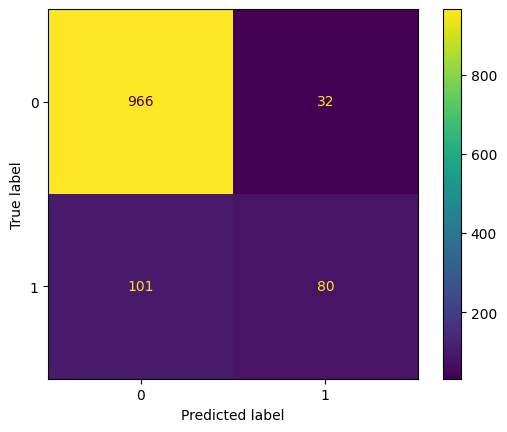

In [42]:
from sklearn.metrics import confusion_matrix

from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=logreg.classes_)

disp = ConfusionMatrixDisplay(cm,display_labels=logreg.classes_)

disp.plot()

KNN

In [43]:
from sklearn.neighbors import KNeighborsClassifier

Text(0, 0.5, 'Mean Error')

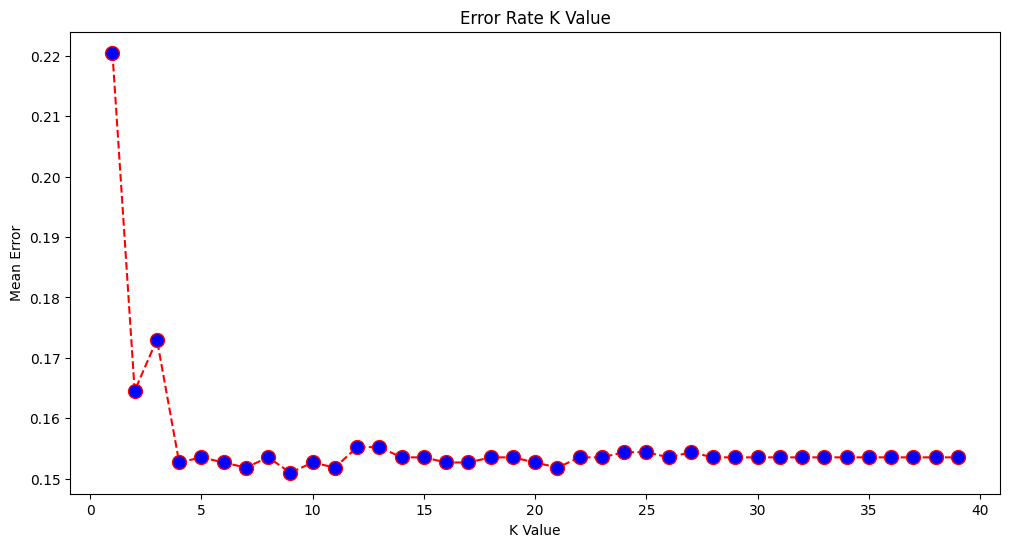

In [44]:
error = []

for i in range(1, 40):
  knn = KNeighborsClassifier(n_neighbors=i)

  knn.fit(X1_train, y_train)

  pred_i = knn.predict(X1_test)

  error.append(np.mean(pred_i != y_test))

plt.figure(figsize=(12, 6))
plt.plot(range(1, 40), error, color='red', linestyle='dashed', marker='o', markerfacecolor='blue', markersize=10)
plt.title('Error Rate K Value')
plt.xlabel('K Value')
plt.ylabel('Mean Error')


In [45]:
knn = KNeighborsClassifier(n_neighbors = 21)

knn.fit(X1_train,y_train)

knn.score(X1_test, y_test)

0.8481764206955047

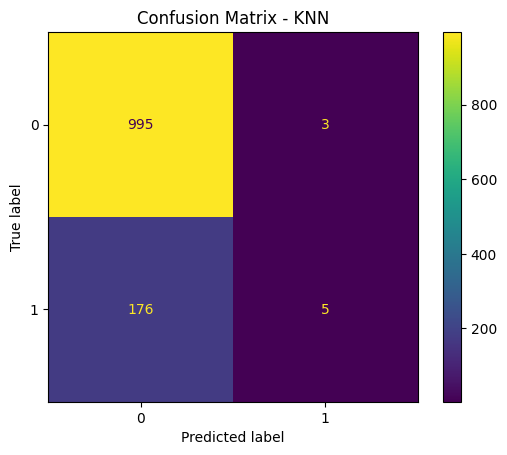

In [46]:
cm_knn = confusion_matrix(y_test, knn.predict(X1_test), labels=knn.classes_)
disp_knn = ConfusionMatrixDisplay(cm_knn, display_labels=knn.classes_)
disp_knn.plot()
plt.title('Confusion Matrix - KNN')
plt.show()

KNN with Grid Search

In [47]:
from sklearn.model_selection import GridSearchCV

In [48]:
knn2 = KNeighborsClassifier()

In [49]:
param_grid = {'n_neighbors': np.arange(1, 25)}
knn_gscv = GridSearchCV(knn2, param_grid, cv=5)

In [50]:
knn_gscv.fit(X1, y)

/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])})

In [51]:
knn_gscv.best_params_

{'n_neighbors': 6}

In [52]:
knn_gscv.best_score_

0.849246851752808

Naive Bayes

In [53]:
from sklearn.naive_bayes import GaussianNB

In [54]:
nb = GaussianNB()

In [55]:
nb.fit(X1_train, y_train)

GaussianNB()

In [56]:
print("Naive Bayes score: ",nb.score(X1_test, y_test))

Naive Bayes score:  0.15606446140797287


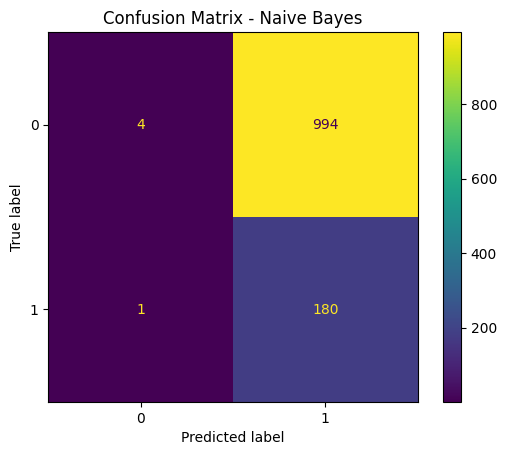

In [57]:
cm_nb = confusion_matrix(y_test, nb.predict(X1_test), labels=nb.classes_)
disp_nb = ConfusionMatrixDisplay(cm_nb, display_labels=nb.classes_)
disp_nb.plot()
plt.title('Confusion Matrix - Naive Bayes')
plt.show()

Performance Evaluation

In [58]:
pip install pycaret

  Using cached scikit_learn-1.4.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
Using cached scikit_learn-1.4.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.1 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.5.2
    Uninstalling scikit-learn-1.5.2:
      Successfully uninstalled scikit-learn-1.5.2


In [12]:
from pycaret.classification import *

s = setup(df_clean_A, target = 'Mortality_Status', ignore_features = ['ID','Sex','MOB'])

,Description,Value
0,Session id,3997
1,Target,Mortality_Status
2,Target type,Multiclass
3,Target mapping,"ALIVE: 0, Alive: 1, DEAD: 2, Dead: 3, alive: 4, dead: 5"
4,Original data shape,"(3927, 18)"
5,Transformed data shape,"(3927, 36)"
6,Transformed train set shape,"(2748, 36)"
7,Transformed test set shape,"(1179, 36)"
8,Ignore features,3
9,Numeric features,6


In [13]:
best_model = compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.8868,0.0000,0.8868,0.8738,0.8726,0.4785,0.5033,2.1390
knn,K Neighbors Classifier,0.8836,0.0000,0.8836,0.8701,0.8697,0.4695,0.4929,0.4520
nb,Naive Bayes,0.4639,0.0000,0.4639,0.8201,0.5841,0.0984,0.1362,0.2340
dt,Decision Tree Classifier,0.8355,0.0000,0.8355,0.8407,0.8377,0.3936,0.3949,0.2410
svm,SVM - Linear Kernel,0.8399,0.0000,0.8399,0.8670,0.8329,0.4009,0.4482,0.3030
ridge,Ridge Classifier,0.8770,0.0000,0.8770,0.8688,0.8475,0.3492,0.4235,0.3400
rf,Random Forest Classifier,0.8981,0.0000,0.8981,0.8893,0.8834,0.5206,0.5559,0.6940
ada,Ada Boost Classifier,0.8930,0.0000,0.8930,0.8837,0.8857,0.5487,0.5585,0.6440
gbc,Gradient Boosting Classifier,0.8908,0.0000,0.8908,0.8822,0.8819,0.5239,0.5379,2.7700
lda,Linear Discriminant Analysis,0.8741,0.0000,0.8741,0.8632,0.8587,0.4171,0.4437,0.4360


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [15]:
best_model = compare_models(sort='Precision')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.8981,0.0000,0.8981,0.8893,0.8834,0.5206,0.5559,1.3620
lightgbm,Light Gradient Boosting Machine,0.8963,0.0000,0.8963,0.8852,0.8850,0.5355,0.5549,2.2860
ada,Ada Boost Classifier,0.8930,0.0000,0.8930,0.8837,0.8857,0.5487,0.5585,0.8690
gbc,Gradient Boosting Classifier,0.8908,0.0000,0.8908,0.8822,0.8819,0.5239,0.5379,3.9180
xgboost,Extreme Gradient Boosting,0.8930,0.0000,0.8930,0.8820,0.8828,0.5304,0.5467,0.5110
lr,Logistic Regression,0.8868,0.0000,0.8868,0.8738,0.8726,0.4785,0.5033,3.0870
knn,K Neighbors Classifier,0.8836,0.0000,0.8836,0.8701,0.8697,0.4695,0.4929,0.4240
ridge,Ridge Classifier,0.8770,0.0000,0.8770,0.8688,0.8475,0.3492,0.4235,0.6500
svm,SVM - Linear Kernel,0.8399,0.0000,0.8399,0.8670,0.8329,0.4009,0.4482,0.9240
lda,Linear Discriminant Analysis,0.8741,0.0000,0.8741,0.8632,0.8587,0.4171,0.4437,0.3950


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [16]:
best_model = compare_models(sort='Recall')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.8981,0.0000,0.8981,0.8893,0.8834,0.5206,0.5559,0.6680
lightgbm,Light Gradient Boosting Machine,0.8963,0.0000,0.8963,0.8852,0.8850,0.5355,0.5549,1.8430
ada,Ada Boost Classifier,0.8930,0.0000,0.8930,0.8837,0.8857,0.5487,0.5585,0.4140
xgboost,Extreme Gradient Boosting,0.8930,0.0000,0.8930,0.8820,0.8828,0.5304,0.5467,0.6240
gbc,Gradient Boosting Classifier,0.8908,0.0000,0.8908,0.8822,0.8819,0.5239,0.5379,3.3500
lr,Logistic Regression,0.8868,0.0000,0.8868,0.8738,0.8726,0.4785,0.5033,1.4990
knn,K Neighbors Classifier,0.8836,0.0000,0.8836,0.8701,0.8697,0.4695,0.4929,0.2490
ridge,Ridge Classifier,0.8770,0.0000,0.8770,0.8688,0.8475,0.3492,0.4235,0.2350
lda,Linear Discriminant Analysis,0.8741,0.0000,0.8741,0.8632,0.8587,0.4171,0.4437,0.2400
et,Extra Trees Classifier,0.8661,0.0000,0.8661,0.8445,0.8398,0.3249,0.3698,0.6960


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [18]:
best_model = compare_models(sort='Accuracy')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.8981,0.0000,0.8981,0.8893,0.8834,0.5206,0.5559,0.8720
lightgbm,Light Gradient Boosting Machine,0.8963,0.0000,0.8963,0.8852,0.8850,0.5355,0.5549,1.7200
ada,Ada Boost Classifier,0.8930,0.0000,0.8930,0.8837,0.8857,0.5487,0.5585,0.5460
xgboost,Extreme Gradient Boosting,0.8930,0.0000,0.8930,0.8820,0.8828,0.5304,0.5467,0.5060
gbc,Gradient Boosting Classifier,0.8908,0.0000,0.8908,0.8822,0.8819,0.5239,0.5379,3.0690
lr,Logistic Regression,0.8868,0.0000,0.8868,0.8738,0.8726,0.4785,0.5033,1.8410
knn,K Neighbors Classifier,0.8836,0.0000,0.8836,0.8701,0.8697,0.4695,0.4929,0.2520
ridge,Ridge Classifier,0.8770,0.0000,0.8770,0.8688,0.8475,0.3492,0.4235,0.2320
lda,Linear Discriminant Analysis,0.8741,0.0000,0.8741,0.8632,0.8587,0.4171,0.4437,0.2450
et,Extra Trees Classifier,0.8661,0.0000,0.8661,0.8445,0.8398,0.3249,0.3698,0.8030


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [19]:
best_model = compare_models(sort='F1')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.8930,0.0000,0.8930,0.8837,0.8857,0.5487,0.5585,0.4090
lightgbm,Light Gradient Boosting Machine,0.8963,0.0000,0.8963,0.8852,0.8850,0.5355,0.5549,2.8640
rf,Random Forest Classifier,0.8981,0.0000,0.8981,0.8893,0.8834,0.5206,0.5559,0.7260
xgboost,Extreme Gradient Boosting,0.8930,0.0000,0.8930,0.8820,0.8828,0.5304,0.5467,0.5110
gbc,Gradient Boosting Classifier,0.8908,0.0000,0.8908,0.8822,0.8819,0.5239,0.5379,3.0300
lr,Logistic Regression,0.8868,0.0000,0.8868,0.8738,0.8726,0.4785,0.5033,1.3920
knn,K Neighbors Classifier,0.8836,0.0000,0.8836,0.8701,0.8697,0.4695,0.4929,0.2540
lda,Linear Discriminant Analysis,0.8741,0.0000,0.8741,0.8632,0.8587,0.4171,0.4437,0.2340
ridge,Ridge Classifier,0.8770,0.0000,0.8770,0.8688,0.8475,0.3492,0.4235,0.2370
et,Extra Trees Classifier,0.8661,0.0000,0.8661,0.8445,0.8398,0.3249,0.3698,0.8330


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

PART (B) Breast Cancer Survival Rate Prediction


In [53]:
encoded_df.shape

(3927, 132)

In [30]:
feature_cols_DT = encoded_df.drop('num__Survival Months', axis = 1).columns
feature_cols_DT

Index(['num__Age', 'num__Occupation Code', 'num__Adopted Status', 'num__Grade',
       'num__Tumor Size', 'cat__Race_Black', 'cat__Race_Other',
       'cat__Race_White', 'cat__Marital Status_Divorced',
       'cat__Marital Status_Married',
       ...
       'cat__Regional Node Positive_4', 'cat__Regional Node Positive_41',
       'cat__Regional Node Positive_46', 'cat__Regional Node Positive_5',
       'cat__Regional Node Positive_6', 'cat__Regional Node Positive_7',
       'cat__Regional Node Positive_8', 'cat__Regional Node Positive_9',
       'cat__Regional Node Positive_One', 'Mortality_Status'],
      dtype='object', length=131)

In [32]:
X = encoded_df[feature_cols]

y = encoded_df['num__Survival Months']

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [41]:
from sklearn.tree import DecisionTreeRegressor

regressor = DecisionTreeRegressor()

regressor.fit(X_train, y_train)

#To make predictions on the test set, ues the predict method:

y_pred = regressor.predict(X_test)

In [42]:
from sklearn import metrics

print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))

print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))

print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Mean Absolute Error: 0.8371501272264631
Mean Squared Error: 542.5114503816794
Root Mean Squared Error: 23.291875201058403


In [43]:
from matplotlib import pyplot as plt

from sklearn import tree

plt.figure(figsize=(200,200))

tree.plot_tree(regressor, feature_names=list(X_train.columns), filled=True)

[Text(0.5858497191011236, 0.9444444444444444, 'num__Survival Months <= 70.5\nsquared_error = 521.63\nsamples = 3141\nvalue = 70.951'),
 Text(0.3514747191011236, 0.8333333333333334, 'num__Survival Months <= 41.5\nsquared_error = 250.443\nsamples = 1512\nvalue = 51.706'),
 Text(0.1853932584269663, 0.7222222222222222, 'num__Survival Months <= 23.5\nsquared_error = 130.35\nsamples = 299\nvalue = 24.525'),
 Text(0.09550561797752809, 0.6111111111111112, 'num__Survival Months <= 13.5\nsquared_error = 39.114\nsamples = 135\nvalue = 13.733'),
 Text(0.05056179775280899, 0.5, 'num__Survival Months <= 7.5\nsquared_error = 10.569\nsamples = 65\nvalue = 8.123'),
 Text(0.028089887640449437, 0.3888888888888889, 'num__Survival Months <= 4.5\nsquared_error = 2.281\nsamples = 28\nvalue = 4.929'),
 Text(0.016853932584269662, 0.2777777777777778, 'cat__Race_Other <= 0.5\nsquared_error = 0.71\nsamples = 13\nvalue = 3.538'),
 Text(0.011235955056179775, 0.16666666666666666, 'num__Survival Months <= 3.5\nsquare

In [45]:
df_clean_A.info()


<class 'pandas.core.frame.DataFrame'>
Index: 3927 entries, 0 to 4023
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     3927 non-null   float64
 1   Race                    3927 non-null   object 
 2   Marital Status          3927 non-null   object 
 3   Occupation Code         3927 non-null   float64
 4   Adopted Status          3927 non-null   int64  
 5   T Stage                 3927 non-null   object 
 6   N Stage                 3927 non-null   object 
 7   6th Stage               3927 non-null   object 
 8   differentiate           3927 non-null   object 
 9   Grade                   3927 non-null   int64  
 10  A Stage                 3927 non-null   object 
 11  Tumor Size              3927 non-null   float64
 12  Estrogen Status         3927 non-null   object 
 13  Progesterone Status     3927 non-null   object 
 14  Regional Node Examined  3927 non-null   objec

In [46]:
encoded_df.columns

Index(['num__Age', 'num__Occupation Code', 'num__Adopted Status', 'num__Grade',
       'num__Tumor Size', 'num__Survival Months', 'cat__Race_Black',
       'cat__Race_Other', 'cat__Race_White', 'cat__Marital Status_Divorced',
       ...
       'cat__Regional Node Positive_4', 'cat__Regional Node Positive_41',
       'cat__Regional Node Positive_46', 'cat__Regional Node Positive_5',
       'cat__Regional Node Positive_6', 'cat__Regional Node Positive_7',
       'cat__Regional Node Positive_8', 'cat__Regional Node Positive_9',
       'cat__Regional Node Positive_One', 'Mortality_Status'],
      dtype='object', length=132)

In [ ]:
df_reg = df_clean_A.drop(['ID','Sex','MOB', 'Race', 'Marital Status','T Stage', 'N Stage', '6th Stage', 'differentiate','A Stage','Estrogen Status', 'Progesterone Status',
       'Regional Node Examined', 'Regional Node Positive'], axis = 1)